** Dataset Path : **

/content/drive/MyDrive/TriageFlow/datasets/aa_dataset-tickets-multi-lang-5-2-50-version.*csv*

In [1]:
with open("/content/drive/MyDrive/TriageFlow/datasets/aa_dataset-tickets-multi-lang-5-2-50-version.csv", "r", encoding="utf-8") as f:
    print(sum(1 for _ in f))

28590


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files


#pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
#pd.set_option('display.max_colwidth', None)
#pd.set_option('display.width', None)


df = pd.read_csv("/content/drive/MyDrive/TriageFlow/datasets/aa_dataset-tickets-multi-lang-5-2-50-version.csv")

In [3]:
print(df.shape)


(28587, 16)


There is a difference of 3 entries instead of only 1 (column names),between df.shape and python file reading.

In [4]:
with open("/content/drive/MyDrive/TriageFlow/datasets/aa_dataset-tickets-multi-lang-5-2-50-version.csv",
          encoding="utf-8") as f:
    lines = f.readlines()

print("Total lines:", len(lines))

for i, line in enumerate(lines[-10:], start=len(lines)-9):
    print(i, repr(line))

Total lines: 28590
28581 'Sichere Medizinische Daten Systeme,"geehrte Kundensupport, ich möchte mich bei Ihnen rüsten, um die angemessenen Sicherheitsmaßnahmen für den Schutz medizinischer Daten in der IT-Infrastruktur eines Krankenhauses umzusetzen. Es ist dringend erforderlich, dass die IT-Systeme des Krankenhauses eine robuste Sicherheitsstruktur besitzen, um vertrauliche Patientendaten vor potenziellen Cyber-Threats zu schützen. Ich freue mich, Ratschläge zu den besten Praktiken und Lösungen für die Sicherung medizinischer Daten zu erhalten, einschließlich Verschlüsselungsmethoden, Zugriffskontrollen und Netzwerksicherheitsprotokollen. Darüber hinaus würde ich Informationen zur regelmäßigen Durchführung von Sicherheitsaudits und Schwachstellenbewertungen zu schätzen wissen, um sicherzustellen, dass das Krankenhaus-IT-System stets den neuesten Sicherheitsstand erreicht. Bitte lassen Sie mich wissen, wann wir uns gerne über diese Angelegenheit weiter besprechen können.","geehrter <na

This shows that there is no extra empty lines at the last of the rows.

In [5]:
#Finding the embedded new line location

import csv

file_path = "/content/drive/MyDrive/TriageFlow/datasets/aa_dataset-tickets-multi-lang-5-2-50-version.csv"

with open(file_path, encoding="utf-8", newline="") as f:
    reader = csv.reader(f)

    previous_physical_line = 1

    for row_number, row in enumerate(reader, start=1):

        current_physical_line = reader.line_num

        physical_lines_used = current_physical_line - previous_physical_line + 1

        if physical_lines_used > 1:
            print(f"CSV row {row_number} occupies {physical_lines_used} physical lines.")
            break

        previous_physical_line = current_physical_line + 1

CSV row 2643 occupies 3 physical lines.


This shows that there is only one record which has 2 extra embedded lines.

Since this is not a multi-lingual support project, and this row is already in a different language than English, so removing this row would be better.

In [6]:
with open(file_path, encoding="utf-8", newline="") as f:
    reader = csv.reader(f)

    for row_number, row in enumerate(reader, start=1):
        for col_idx, value in enumerate(row):
            if "\n" in value:
                print(f"CSV row: {row_number}")
                print(f"Column: {col_idx}")
                print("Embedded newline found.")
                print(repr(value))

CSV row: 2643
Column: 12
Embedded newline found.
'System\n\n'


In [7]:
df.iloc[2641]

,2641
subject,Fehlerhafte Verarbeitung von Finanzdaten
body,"Sehr geehrter Kundenservice, ich möchte ein sc..."
answer,"Sehr geehrte/r <name>, ich bestätige den Erhal..."
type,Incident
queue,Technical Support
priority,high
language,de
version,52
tag_1,Bug
tag_2,Performance


This shows that we need to remove the row 2641, since it has 2 extra embedded newlines and it is also not in English language

In [8]:
print(df.columns)

Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6',
       'tag_7', 'tag_8'],
      dtype='object')


In [9]:
df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28587 entries, 0 to 28586
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   subject   24749 non-null  object
 1   body      28587 non-null  object
 2   answer    28580 non-null  object
 3   type      28587 non-null  object
 4   queue     28587 non-null  object
 5   priority  28587 non-null  object
 6   language  28587 non-null  object
 7   version   28587 non-null  int64 
 8   tag_1     28587 non-null  object
 9   tag_2     28574 non-null  object
 10  tag_3     28451 non-null  object
 11  tag_4     25529 non-null  object
 12  tag_5     14545 non-null  object
 13  tag_6     5874 non-null   object
 14  tag_7     2040 non-null   object
 15  tag_8     565 non-null    object
dtypes: int64(1), object(15)
memory usage: 3.5+ MB


In [11]:
df.describe(include="all")

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
count,24749,28587,28580,28587,28587,28587,28587,28587.000000,28587,28574,28451,25529,14545,5874,2040,565
unique,24749,28587,28580,4,10,3,2,NaN,116,256,392,554,602,575,427,224
top,Inquiry About Project Management Features,Looking for detailed information on the projec...,"Dear [Name], thank you for your email regardin...",Incident,Technical Support,medium,en,NaN,Security,Performance,IT,Tech Support,Tech Support,Tech Support,Tech Support,Tech Support
freq,1,1,1,11466,8362,11515,16338,NaN,5880,5903,6121,6568,4617,1847,391,77
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,278.382027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,165.962935,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,400.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,400.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df["queue"].value_counts(dropna=False)

,count
queue,
Technical Support,8362
Product Support,5252
Customer Service,4268
IT Support,3433
Billing and Payments,2788
Returns and Exchanges,1437
Service Outages and Maintenance,1148
Sales and Pre-Sales,918
Human Resources,576


In [13]:
df["version"].value_counts(dropna=False)

,count
version,
400,18599
52,9119
51,869


In [14]:
df.isnull().sum()

,0
subject,3838
body,0
answer,7
type,0
queue,0
priority,0
language,0
version,0
tag_1,0
tag_2,13


In [15]:
df["body"].nunique()

28587

In [16]:
df["subject"].nunique()

24749

In [17]:
df["answer"].nunique()

28580

In [18]:
print(df["answer"].isnull().sum())

7


Found 7 rows with no replies or null value entry in the 'answer' feature

In [19]:
df["language"].value_counts()

,count
language,
en,16338
de,12249


In [20]:
print(df["language"].unique())

['de' 'en']


There are entries in two different langauges. So, we'll only keep the entries which are in English language only as it's not a multi-lingual support project.

Checking the 'body' feature entries of the rows where the 'subject' feature entries are missing.




In [21]:
df.loc[df["subject"].isna(), "body"].head(10)

,body
870,"Customer Support, I am requesting comprehensiv..."
887,"Customer Support,\n\nI am reporting a critical..."
888,Die Leistung der digitalen Kampagnen unserer M...
915,"Customer Support, drafting a request for enhan..."
929,Customer support has received a report regardi...
933,Customer Support is reaching out to request gu...
934,"Sehr geehrter Kundenservice,\n\nich möchte ein..."
946,"Dear Customer Support, I am reaching out to re..."
949,Facing challenges with the marketing agency's ...
950,I am seeking comprehensive integration instruc...


In [22]:
#missing_subject = df["subject"].isna()
#print(missing_subject.sum())

In [23]:
#def create_subject(body):
#    words = body.split()
#    subject = " ".join(words[:12])
#    return subject


#df.loc[missing_subject, "subject"] = (
#    df.loc[missing_subject, "body"].apply(create_subject)
#)

In [24]:
#print(df["subject"].isna().sum())

In [25]:
df.columns

Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6',
       'tag_7', 'tag_8'],
      dtype='object')

In [26]:
df["type"].value_counts()

,count
type,
Incident,11466
Request,8187
Problem,6012
Change,2922


In [27]:
df["priority"].value_counts()

,count
priority,
medium,11515
high,11178
low,5894


In [28]:
df[["tag_1", "tag_2", "tag_3", "tag_4", "tag_5", "tag_6", "tag_7", "tag_8"]].nunique()

,0
tag_1,116
tag_2,256
tag_3,392
tag_4,554
tag_5,602
tag_6,575
tag_7,427
tag_8,224


In [29]:
df["tag_1"].unique()[:20]

array(['Security', 'Account', 'Product', 'Billing', 'Feature', 'Outage',
       'Network', 'Documentation', 'Disruption', 'Bug', 'Inquiry',
       'Marketing', 'Hardware', 'Video', 'Organization', 'Finance',
       'Feedback', 'Refund', 'API', 'Compliance'], dtype=object)

In [30]:
df["tag_2"].unique()[:20]

array(['Outage', 'Disruption', 'Feature', 'Payment', 'Product',
       'Hardware', 'Feedback', 'Performance', 'Crash', 'Service', 'Issue',
       'Account', 'Maintenance', 'Documentation', 'Security',
       'Tech Support', 'Compliance', 'Bug', 'Connectivity', 'IT'],
      dtype=object)

In [31]:
df["tag_3"].unique()[:20]

array(['Disruption', 'Outage', 'Tech Support', 'Account', 'Feedback',
       'Documentation', 'Performance', 'IT', 'Recovery', 'VPN', 'Network',
       'Feature', 'Marketing', 'Sales', 'Notification', 'Security',
       'Compatibility', 'Subscription', 'Hardware', 'Connectivity'],
      dtype=object)

In [32]:
df["tag_4"].unique()[:20]

array(['Data Breach', 'IT', nan, 'Documentation', 'Tech Support',
       'Feedback', 'Bug', 'Support', 'Feature', 'Performance', 'Sales',
       'Customer Support', 'Lead', 'Product', 'Audio', 'Disruption',
       'Assistance', 'Compatibility', 'Emergency', 'Hardware'],
      dtype=object)

In [33]:
df["tag_5"].unique()[:20]

array([nan, 'Tech Support', 'Feedback', 'Compatibility', 'Disruption',
       'Automation', 'IT', 'Support', 'Performance', 'Cloud', 'Network',
       'Sales', 'Platform', 'Hardware', 'Recovery', 'Maintenance', 'SaaS',
       'Update', 'Issue', 'Notification'], dtype=object)

In [34]:
df["tag_6"].unique()[:20]

array([nan, 'Outage', 'Organization', 'Tech Support', 'IT',
       'Microservice', 'Performance', 'Service', 'Document',
       'Technical Support', 'Data Privacy', 'Support', 'Software',
       'Disruption', 'Refund', 'Customer Support', 'System', 'Stability',
       'Maintenance', 'Troubleshooting'], dtype=object)

In [35]:
df["tag_7"].unique()[:20]

array([nan, 'Tech Support', 'Campaign', 'Workflow', 'Connection',
       'Troubleshooting', 'Hardware', 'Recovery', 'Infrastructure',
       'Availability', 'Modern Technology', 'Real-time Analytics', 'IoT',
       'IT', 'Feedback', 'Failure', 'Issue', 'Documentation',
       'Maintenance', 'Stability'], dtype=object)

In [36]:
df["tag_8"].unique()[:20]

array([nan, 'Tech Support', 'Ink', 'Maintenance', 'IT', 'Healthcare',
       'Customer Service', 'Issue', 'Data Synchronization', 'SaaS', 'EMR',
       'Support', 'Firmware', 'Documentation', 'Best Practices',
       'Guidance', 'Case Study', 'Brand Awareness', 'Strategy',
       'Promotion'], dtype=object)

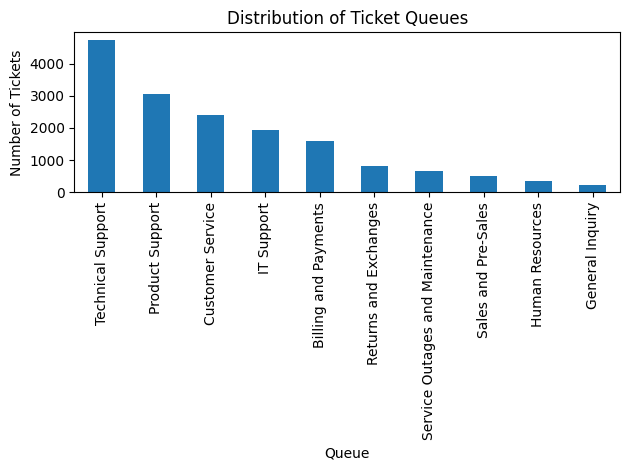

In [72]:
df["queue"].value_counts().plot(kind="bar")
plt.title("Distribution of Ticket Queues")
plt.xlabel("Queue")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()

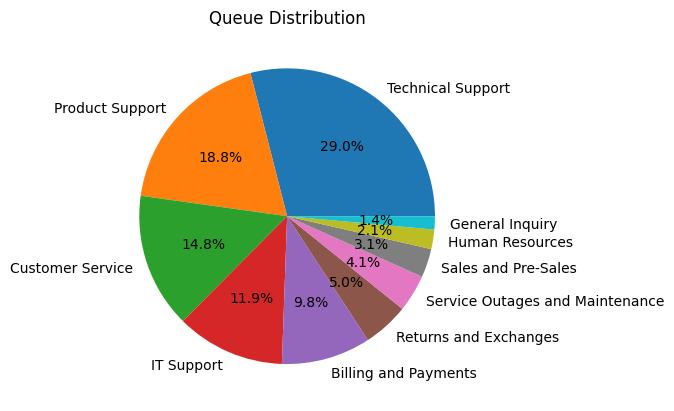

In [73]:
df["queue"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")
plt.title("Queue Distribution")
plt.show()

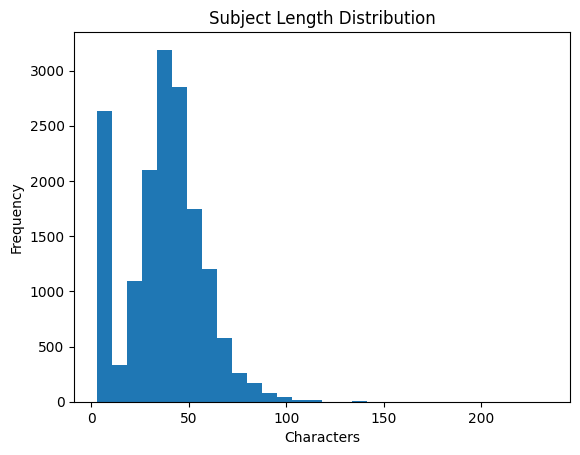

In [74]:
df["subject_length"] = df["subject"].str.len()

plt.hist(df["subject_length"], bins=30)

plt.title("Subject Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

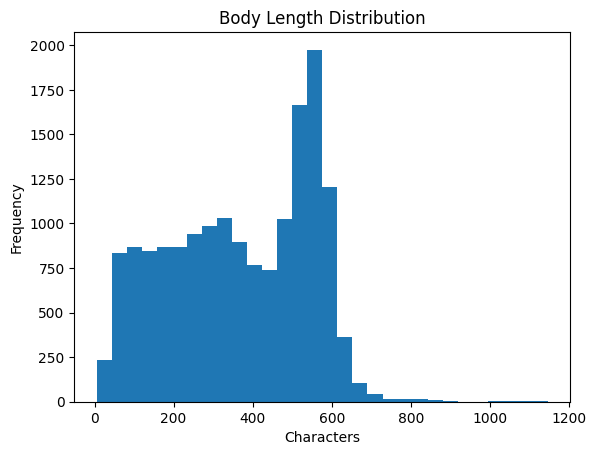

In [75]:
df["body_length"] = df["body"].str.len()
plt.hist(df["body_length"], bins=30)
plt.title("Body Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

# **Preprocessing starts here**

**Data Filtering**

Removing this row, since it has two unnecessary extra embedded lines, also the entry is not in English language

In [37]:
df = df.drop(index=2641).reset_index(drop=True)

Removing the rows containing 7 null entries in the 'answer' column

In [38]:
df = df.dropna(subset=["answer"])

Removing all row entries which are not in English language as multi-lingual support is not in the scope of this project.

In [39]:
df = df[df["language"] == "en"]

In [40]:
df = df.reset_index(drop=True)

**Feature Selection**

Dropping the whole language column from the dataset as all the row entries are now in English.

In [41]:
df = df.drop(columns=["language"])

Removing the 'version' feature from the dataset, as the source of this dataset clearly mentioned that this 'version' feature is irrelevant.

In [42]:
df = df.drop(columns=["version"])

These 'tags' columns are manually assigned metadata, that is Unavailable when a new customer submits a ticket. Since the classifier must work only with information available at prediction time, the tag columns were excluded to avoid complexity.

In [43]:
df = df.drop(columns=[
    "tag_1",
    "tag_2",
    "tag_3",
    "tag_4",
    "tag_5",
    "tag_6",
    "tag_7",
    "tag_8"
])

**Contant Value Imputation**

In [44]:
df.isnull().sum()

,0
subject,2606
body,0
answer,0
type,0
queue,0
priority,0


In [45]:
# Replacing all the null values from the subject column to "No Subject" text
df["subject"] = df["subject"].fillna("No Subject")

**Feature Construction**

For each new row of the new column 'query_text', if the subject is 'No Subject', then I'm using only the body. Otherwise, I'm combining the subject and the body for the values of the new column.

In [46]:
#np.where(condition, if_true, if_false)
df["query_text"] = np.where(df["subject"] == "No Subject",
    df["body"],
    df["subject"] + " " + df["body"]
)

**Data Preparation**

In [47]:
df = df[
    [
        "subject",
        "body",
        "query_text",
        "answer",
        "queue",
        "priority",
        "type"
    ]
]

In [48]:
df.to_csv("cleaned_dataset.csv", index=False)

In [49]:
files.download("cleaned_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Dataset Validation**

In [50]:
df.shape

(16335, 7)

In [51]:
df.columns.tolist()

['subject', 'body', 'query_text', 'answer', 'queue', 'priority', 'type']

In [52]:
df.isnull().sum()

,0
subject,0
body,0
query_text,0
answer,0
queue,0
priority,0
type,0


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16335 entries, 0 to 16334
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   subject     16335 non-null  object
 1   body        16335 non-null  object
 2   query_text  16335 non-null  object
 3   answer      16335 non-null  object
 4   queue       16335 non-null  object
 5   priority    16335 non-null  object
 6   type        16335 non-null  object
dtypes: object(7)
memory usage: 893.4+ KB


Reduced the memory usage significantly after performing the eda and preprocessing. Dropped memory usage from 3.5+ MB to 765.8+ KB.

In [54]:
df.nunique()

,0
subject,13730
body,16335
query_text,16335
answer,16335
queue,10
priority,3
type,4


In [55]:
df.head()

,subject,body,query_text,answer,queue,priority,type
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Account Disruption Dear Customer Support Team,...","Thank you for reaching out, <name>. We are awa...",Technical Support,high,Incident
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Query About Smart Home System Integration Feat...,Thank you for your inquiry. Our products suppo...,Returns and Exchanges,medium,Request
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Inquiry Regarding Invoice Details Dear Custome...,We appreciate you reaching out with your billi...,Billing and Payments,low,Request
3,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Question About Marketing Agency Software Compa...,Thank you for your inquiry. Our product suppor...,Sales and Pre-Sales,medium,Problem
4,Feature Query,"Dear Customer Support,\n\nI hope this message ...","Feature Query Dear Customer Support,\n\nI hope...",Thank you for your inquiry. Please specify whi...,Technical Support,high,Request


In [56]:
df.describe(include='all')

,subject,body,query_text,answer,queue,priority,type
count,16335,16335,16335,16335,16335,16335,16335
unique,13730,16335,16335,16335,10,3,4
top,No Subject,Looking for detailed information on the projec...,Inquiry About Project Management Features Look...,"Dear [Name], thank you for your email regardin...",Technical Support,medium,Incident
freq,2606,1,1,1,4736,6616,6571


In [57]:
print(df.duplicated().sum())

0


In [58]:
print(df.duplicated(subset=["subject", "body"]).sum())

0


In [59]:
df.duplicated(subset=["subject", "body"]).sum()

np.int64(0)

In [60]:
df["body"].nunique()

16335

In [61]:
df["answer"].nunique()

16335

In [62]:
df["subject"].nunique()

13730

In [63]:
df["type"].value_counts()

,count
type,
Incident,6571
Request,4665
Problem,3394
Change,1705


In [64]:
df["priority"].value_counts()

,count
priority,
medium,6616
high,6345
low,3374


In [65]:
df["subject"].str.len().describe()

,subject
count,16335.000000
mean,38.247322
std,18.816906
min,3.000000
25%,27.000000
50%,39.000000
75%,50.000000
max,234.000000


In [66]:
df["body"].str.len().describe()

,body
count,16335.000000
mean,367.900398
std,179.883979
min,6.000000
25%,214.000000
50%,377.000000
75%,533.000000
max,1147.000000


In [67]:
df["answer"].str.len().describe()

,answer
count,16335.000000
mean,365.193327
std,163.091312
min,4.000000
25%,220.000000
50%,374.000000
75%,516.000000
max,885.000000


In [68]:
df.sample(5)

,subject,body,query_text,answer,queue,priority,type
4435,Inquiry Regarding Digital Strategy Offerings,"Hello Customer Support, I am reaching out to i...",Inquiry Regarding Digital Strategy Offerings H...,"<name>, thank you for your interest in our dig...",Sales and Pre-Sales,low,Request
14222,No Subject,Enhance security measures to protect medical d...,Enhance security measures to protect medical d...,<name> values the suggestion to enhance securi...,Product Support,high,Change
8457,System Crashes During Project Exports,We are facing system crashes during project ex...,System Crashes During Project Exports We are f...,We are investigating the system crashes encoun...,Technical Support,high,Incident
2719,Problem with Data Tools,An incident involving data analytics tools has...,Problem with Data Tools An incident involving ...,Please investigate the problem with the data a...,Product Support,medium,Incident
11397,Challenges with Digital Marketing Tools,Our digital marketing tools are not functionin...,Challenges with Digital Marketing Tools Our di...,{name} has acknowledged receipt of the email r...,IT Support,high,Incident


In [69]:
df["queue"].value_counts()

,count
queue,
Technical Support,4736
Product Support,3071
Customer Service,2410
IT Support,1942
Billing and Payments,1595
Returns and Exchanges,820
Service Outages and Maintenance,664
Sales and Pre-Sales,513
Human Resources,348


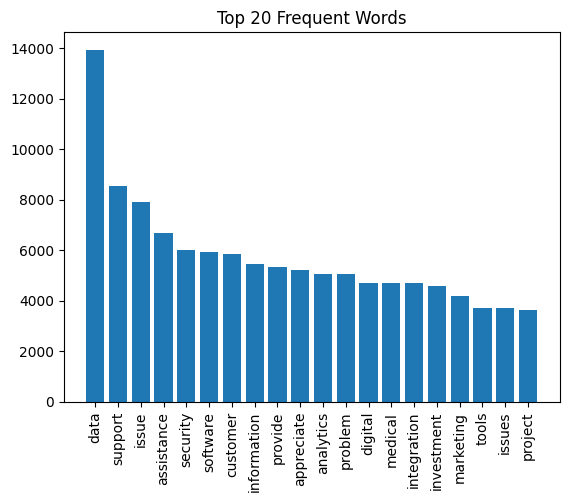

In [77]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words="english")
X = vectorizer.fit_transform(df["query_text"])
word_counts = X.sum(axis=0).A1
words = vectorizer.get_feature_names_out()
freq = pd.DataFrame({"word": words, "count": word_counts})
freq = freq.sort_values("count",ascending=False).head(20)
plt.bar(freq["word"], freq["count"])
plt.xticks(rotation=90)
plt.title("Top 20 Frequent Words")
plt.show()

/tmp/ipykernel_605/2621095308.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


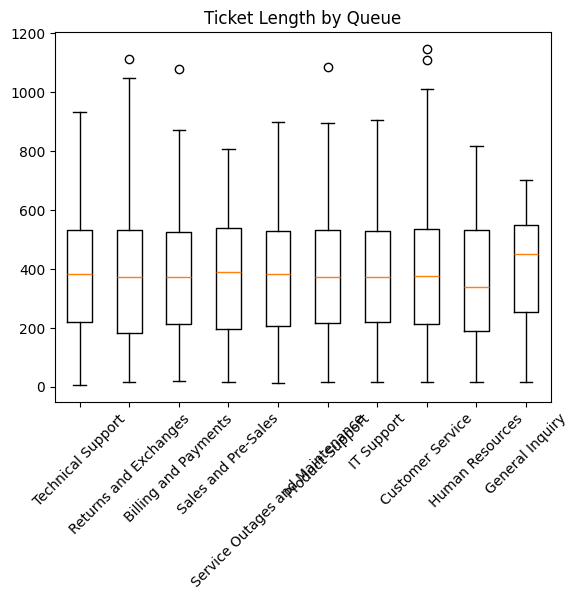

In [80]:
plt.boxplot(
[
df[df["queue"]==q]["body_length"]
for q in df["queue"].unique()], labels=df["queue"].unique())

plt.title("Ticket Length by Queue")
plt.xticks(rotation=45)
plt.show()

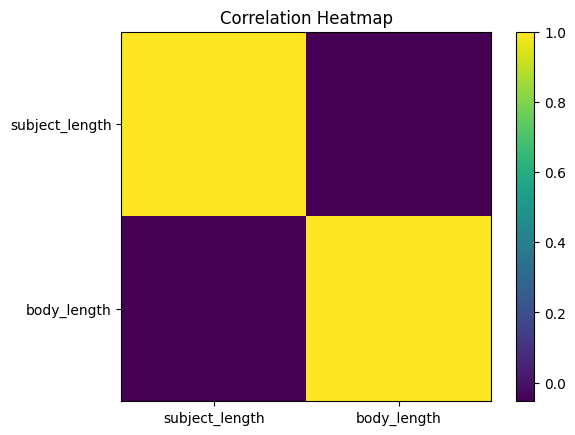

In [81]:
numeric = df[["subject_length","body_length"]]
corr = numeric.corr()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()